# EDA

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score, roc_auc_score

import random

import re
import string

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/datasets/Final_Project/train.csv'
df = pd.read_csv(path)

In [ ]:
df.head()

,review,sentiment
0,I caught this little gem totally by accident b...,positive
1,I can't believe that I let myself into this mo...,negative
2,*spoiler alert!* it just gets to me the nerve ...,negative
3,If there's one thing I've learnt from watching...,negative
4,"I remember when this was in theaters, reviews ...",negative


In [ ]:
df.describe().T

,count,unique,top,freq
review,40000,39728,Loved today's show!!! It was a variety and not...,5
sentiment,40000,2,positive,20000


In [ ]:
len(df)

40000

In [ ]:
df['review'].str.len().sum()

np.int64(52421978)

In [ ]:
df['review'].str.len().mean()

np.float64(1310.54945)

In [ ]:
df['review'].str.len().min()

41

In [ ]:
df['review'].str.len().max()

13704

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,20000
negative,20000


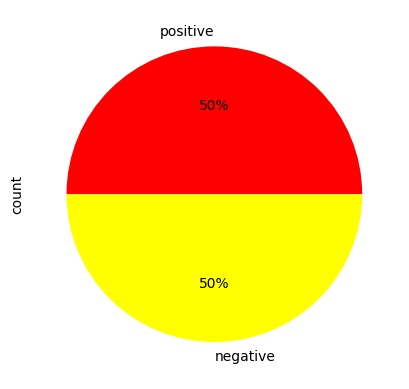

In [ ]:
df.sentiment.value_counts().plot(kind='pie', autopct='%1.0f%%', colors=["red", "yellow"])
plt.show()

# Feature Engineering

## Experimantations

### Some preprocessing

In [ ]:
df_2 = df.copy()

In [ ]:
df_2['sentiment'] = df_2['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
df_2['review_lower_case'] = df_2['review'].str.lower()

Lowercased so that similar words are treated the same way like good and Good.

In [ ]:
df_2.head()

,review,sentiment,review_lower_case
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ..."


In [ ]:
punctuation = string.punctuation.replace("'", "")
df_2['review_punctuation_removed'] = df_2['review_lower_case'].str.replace(
    f"[{punctuation}]",
    "",
    regex=True
)

removed punctuations but kept " ' " not to lose negations like don't. It would have become a word dont.

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...


### Tokenization

In [ ]:
df_2['tokens'] = df_2['review_punctuation_removed'].apply(word_tokenize)

tokenized by words

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...,"[i, caught, this, little, gem, totally, by, ac..."
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...,"[i, ca, n't, believe, that, i, let, myself, in..."
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...,"[spoiler, alert, it, just, gets, to, me, the, ..."
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...,"[if, there, 's, one, thing, i, 've, learnt, fr..."
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...,"[i, remember, when, this, was, in, theaters, r..."


### Stop - words filtering

In [ ]:
stop_words = set(stopwords.words('english'))

negations = {'no', 'not', 'nor', 'never', 'none', 'nobody', 'nothing', 'nowhere'}
stop_words = stop_words - negations

df_2['tokens_wo_stopwords'] = df_2['tokens'].apply(lambda x: [w for w in x if w.isalpha() and w not in stop_words])

filtered out stopwords. They are not really meaningful and occurs too many times. but I kept negations because they carry huge meaning especially in sentiment analysis.

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens,tokens_wo_stopwords
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...,"[i, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,..."
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...,"[i, ca, n't, believe, that, i, let, myself, in...","[ca, believe, let, movie, accomplish, favor, f..."
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...,"[spoiler, alert, it, just, gets, to, me, the, ...","[spoiler, alert, gets, nerve, people, remake, ..."
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...,"[if, there, 's, one, thing, i, 've, learnt, fr...","[one, thing, learnt, watching, george, romero,..."
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...,"[i, remember, when, this, was, in, theaters, r...","[remember, theaters, reviews, said, horrible, ..."


### Stemming and Lemmatization

In [ ]:
stemmer = PorterStemmer()

df_2['tokens_stemmed'] = df_2['tokens_wo_stopwords'].apply(lambda x: [stemmer.stem(w) for w in x])

reduced tokens to their stem. As you can see here many words' form is quite strange. Like 'accid', 'rememb' ... . That is how stemming works. I will try lemmatization too, it works way better as it gives words' lemma(real base form).

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens,tokens_wo_stopwords,tokens_stemmed
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...,"[i, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...","[caught, littl, gem, total, accid, back, reviv..."
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...,"[i, ca, n't, believe, that, i, let, myself, in...","[ca, believe, let, movie, accomplish, favor, f...","[ca, believ, let, movi, accomplish, favor, fri..."
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...,"[spoiler, alert, it, just, gets, to, me, the, ...","[spoiler, alert, gets, nerve, people, remake, ...","[spoiler, alert, get, nerv, peopl, remak, use,..."
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...,"[if, there, 's, one, thing, i, 've, learnt, fr...","[one, thing, learnt, watching, george, romero,...","[one, thing, learnt, watch, georg, romero, cre..."
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...,"[i, remember, when, this, was, in, theaters, r...","[remember, theaters, reviews, said, horrible, ...","[rememb, theater, review, said, horribl, well,..."


In [ ]:
df_2['tokens_stemmed'] = df_2['tokens_stemmed'].apply(lambda x: ' '.join(x))

Joined the tokens into one string, so now documents are strings again for vectorization.

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens,tokens_wo_stopwords,tokens_stemmed
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...,"[i, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...",caught littl gem total accid back reviv theatr...
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...,"[i, ca, n't, believe, that, i, let, myself, in...","[ca, believe, let, movie, accomplish, favor, f...",ca believ let movi accomplish favor friend ask...
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...,"[spoiler, alert, it, just, gets, to, me, the, ...","[spoiler, alert, gets, nerve, people, remake, ...",spoiler alert get nerv peopl remak use term lo...
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...,"[if, there, 's, one, thing, i, 've, learnt, fr...","[one, thing, learnt, watching, george, romero,...",one thing learnt watch georg romero creepshow ...
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...,"[i, remember, when, this, was, in, theaters, r...","[remember, theaters, reviews, said, horrible, ...",rememb theater review said horribl well think ...


In [ ]:
lemmatizer = WordNetLemmatizer()

df_2['tokens_lemmatized'] = df_2['tokens_wo_stopwords'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

now reduced the tokens to their lemma. here you can see that the forms are way better looking(their forms are correct). Because lemmatization actually gives base form of the word from dictionary so it is better approach usually than stemming.

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens,tokens_wo_stopwords,tokens_stemmed,tokens_lemmatized
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...,"[i, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...",caught littl gem total accid back reviv theatr...,"[caught, little, gem, totally, accident, back,..."
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...,"[i, ca, n't, believe, that, i, let, myself, in...","[ca, believe, let, movie, accomplish, favor, f...",ca believ let movi accomplish favor friend ask...,"[ca, believe, let, movie, accomplish, favor, f..."
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...,"[spoiler, alert, it, just, gets, to, me, the, ...","[spoiler, alert, gets, nerve, people, remake, ...",spoiler alert get nerv peopl remak use term lo...,"[spoiler, alert, get, nerve, people, remake, u..."
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...,"[if, there, 's, one, thing, i, 've, learnt, fr...","[one, thing, learnt, watching, george, romero,...",one thing learnt watch georg romero creepshow ...,"[one, thing, learnt, watching, george, romero,..."
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...,"[i, remember, when, this, was, in, theaters, r...","[remember, theaters, reviews, said, horrible, ...",rememb theater review said horribl well think ...,"[remember, theater, review, said, horrible, we..."


In [ ]:
df_2['tokens_lemmatized'] = df_2['tokens_lemmatized'].apply(lambda x: ' '.join(x))

again joined the tokens for vectorization

In [ ]:
df_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens,tokens_wo_stopwords,tokens_stemmed,tokens_lemmatized
0,I caught this little gem totally by accident b...,1,i caught this little gem totally by accident b...,i caught this little gem totally by accident b...,"[i, caught, this, little, gem, totally, by, ac...","[caught, little, gem, totally, accident, back,...",caught littl gem total accid back reviv theatr...,caught little gem totally accident back reviva...
1,I can't believe that I let myself into this mo...,0,i can't believe that i let myself into this mo...,i can't believe that i let myself into this mo...,"[i, ca, n't, believe, that, i, let, myself, in...","[ca, believe, let, movie, accomplish, favor, f...",ca believ let movi accomplish favor friend ask...,ca believe let movie accomplish favor friend a...
2,*spoiler alert!* it just gets to me the nerve ...,0,*spoiler alert!* it just gets to me the nerve ...,spoiler alert it just gets to me the nerve som...,"[spoiler, alert, it, just, gets, to, me, the, ...","[spoiler, alert, gets, nerve, people, remake, ...",spoiler alert get nerv peopl remak use term lo...,spoiler alert get nerve people remake use term...
3,If there's one thing I've learnt from watching...,0,if there's one thing i've learnt from watching...,if there's one thing i've learnt from watching...,"[if, there, 's, one, thing, i, 've, learnt, fr...","[one, thing, learnt, watching, george, romero,...",one thing learnt watch georg romero creepshow ...,one thing learnt watching george romero creeps...
4,"I remember when this was in theaters, reviews ...",0,"i remember when this was in theaters, reviews ...",i remember when this was in theaters reviews s...,"[i, remember, when, this, was, in, theaters, r...","[remember, theaters, reviews, said, horrible, ...",rememb theater review said horribl well think ...,remember theater review said horrible well thi...


In [ ]:
X_stem = df_2['tokens_stemmed']
y_stem = df_2['sentiment']

X_train_stem, X_test_stem, y_train_stem, y_test_stem = train_test_split(X_stem, y_stem, test_size=0.3, random_state= 42, stratify=y_stem)

In [ ]:
X_train_stem.shape, X_test_stem.shape, y_train_stem.shape, y_test_stem.shape

((28000,), (12000,), (28000,), (12000,))

In [ ]:
X_lemma = df_2['tokens_lemmatized']
y_lemma = df_2['sentiment']

X_train_lemma, X_test_lemma, y_train_lemma, y_test_lemma = train_test_split(X_lemma, y_lemma, test_size = 0.3, random_state=42, stratify=y_lemma)

In [ ]:
X_train_lemma.shape, X_test_lemma.shape, y_train_lemma.shape, y_test_lemma.shape

((28000,), (12000,), (28000,), (12000,))

###Vectorization

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=5
)

X_train_stem_tfidf = tfidf.fit_transform(X_train_stem)
X_test_stem_tfidf = tfidf.transform(X_test_stem)

X_train_lemma_tfidf = tfidf.fit_transform(X_train_lemma)
X_test_lemma_tfidf = tfidf.transform(X_test_lemma)

here vectorized the data. first used TF-IDF vectorizaation method. It is quite interesting and powerful method for vectorization. Bag of Words or n-Grams just record the frequency of the words in the documents and return the matrix with values of frequencies of the words or n words. But TF-IDF 's method is a bit different. It also captures the importance of the words. Also experimented with different n grams(2 and 3). 3 worked better cause it captures more meanings like in case there is 'not', 'good' seperately meaning cannot be captured but if it is 'not good' then it is a different story the same goes for n being 3.

TF(Term Frequency) - calculates : number of times word appeares in the document / total number of words in the document. [In a sense, it is kind of similar to other methods]

IDF(Inversed Document Frequency) - calculates : log( total number of documents / number of documents containing the word) [here importance of the word is captured. If word occurs in too many documents then it is considered not important and number becomes small. If word occurs in few documents then it is considered important and number is huge. Also min and max df s are included so that some typos or very rare words and words occuring in almost all documents are ignored]

In [ ]:
X_train_stem_tfidf.shape, X_test_stem_tfidf.shape

((28000, 117402), (12000, 117402))

In [ ]:
X_train_lemma_tfidf.shape, X_test_lemma_tfidf.shape

((28000, 112984), (12000, 112984))

In [ ]:
count = CountVectorizer(
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=5
)

X_train_stem_count = count.fit_transform(X_train_stem)
X_test_stem_count = count.transform(X_test_stem)

X_train_lemma_count = count.fit_transform(X_train_lemma)
X_test_lemma_count = count.transform(X_test_lemma)

In [ ]:
X_train_stem_count.shape, X_test_stem_count.shape

((28000, 117402), (12000, 117402))

In [ ]:
X_train_lemma_count.shape, X_test_lemma_count.shape

((28000, 112984), (12000, 112984))

implemented n grams with CountVectorizer. It is another vectorization method that only tracks the frequency of the words or n grams over all of the documents. Unlike TF-IDF it does not capture the imortance of the words but just count them.

# Modeling

## Baseline model without preprocessing

In [ ]:
X_raw = df['review']
y_raw = df['sentiment']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42, stratify = y_raw)

tfidf_raw = TfidfVectorizer(
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=5
)

X_train_raw_tfidf = tfidf_raw.fit_transform(X_train_raw)
X_test_raw_tfidf = tfidf_raw.transform(X_test_raw)

lr_raw = LogisticRegression(max_iter=1000, random_state=42)

lr_raw.fit(X_train_raw_tfidf, y_train_raw)

y_pred_raw = lr_raw.predict(X_test_raw_tfidf)

print(f"Accuracy(baseline): {accuracy_score(y_test_raw, y_pred_raw)}")

Accuracy(baseline): 0.9003333333333333


In [ ]:
svm_raw = LinearSVC(max_iter=3000, random_state=42)

svm_raw.fit(X_train_raw_tfidf, y_train_raw)

y_pred_raw = svm_raw.predict(X_test_raw_tfidf)
y_proba_raw = svm_raw.decision_function(X_test_raw_tfidf)

print(f"Accuracy(baseline): {accuracy_score(y_test_raw, y_pred_raw)}")
print(f"ROC AUC(baseline): {roc_auc_score(y_test_raw, y_proba_raw)}")

Accuracy(baseline): 0.9136666666666666
ROC AUC(baseline): 0.9716340277777777


In [ ]:
nb_raw = MultinomialNB()

nb_raw.fit(X_train_raw_tfidf, y_train_raw)

y_pred_raw = nb_raw.predict(X_test_raw_tfidf)

print(f"Accuracy(baseline): {accuracy_score(y_test_raw, y_pred_raw)}")

Accuracy(baseline): 0.8908333333333334


First tried with raw data. Here I just got the raw data, vectorized it and gave it to the models(no tokenization, no removing or filtering anything) and the results are better than the models trained on preprocessed data. The reason is, during preprocessing some meaningful information is lost so models performing better with raw data. Also I went with tfidf vectorization since it performed better and is a better technique too. So out of all models SVM 's performance is the best. I thought Logistic Regression would be a baseline and way lower than others but it worked really well surprisingly. Naive Bayes on the other hand has the lowest score out of them that is natural since it expects the features to be independent which is quite impossible especially here in textual data. Textual data after vectorization becomes well linearly seperable in very high dimensions so linear models such as LR and SVM works really well with that. Some even say that these models were made for this).

Also I am using only accuracy score to evaluate the models because the dataset is balanced and while splitting the data I made sure that train and test data is balanced too by stratifying.

The best score here among 3 models with raw data training is 0.91366 in SVM

## Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_stem_tfidf, y_train_stem)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_stem_tfidf)

print(f"Accuracy(with stemming and tfidf): {accuracy_score(y_test_stem, y_pred_lr)}")

Accuracy(with stemming and tfidf): 0.89375


In [ ]:
lr.fit(X_train_lemma_tfidf, y_train_lemma)

y_pred_lr = lr.predict(X_test_lemma_tfidf)

print(f"Accuracy(with lemmatization and tfidf): {accuracy_score(y_test_lemma, y_pred_lr)}")

Accuracy(with lemmatization and tfidf): 0.8951666666666667


In [ ]:
lr.fit(X_train_stem_count, y_train_stem)

y_pred_lr = lr.predict(X_test_stem_count)

print(f"Accuracy(with stemming and count): {accuracy_score(y_test_stem, y_pred_lr)}")

Accuracy(with stemming and count): 0.8898333333333334


In [ ]:
lr.fit(X_train_lemma_count, y_train_lemma)

y_pred_lr = lr.predict(X_test_lemma_count)

print(f"Accuracy(with lemmatization and count): {accuracy_score(y_test_lemma, y_pred_lr)}")

Accuracy(with lemmatization and count): 0.8928333333333334


Then I experimented with models with various preprocessed data. As expected stemming breaks the forms of the words often so performs a bit worse than lemmatization. Also tried different vectorization techniques and again as expected TF-IDF won. Because of its ability to capture the importance of the grams it captures more meaning in the data.

So the combination of the lemmatization and TF-IDF vectorization won in LR with 0.89516 accuracy score


## SVM

In [ ]:
svm = LinearSVC(max_iter=3000, random_state=42)
svm.fit(X_train_stem_tfidf, y_train_stem)

LinearSVC(max_iter=3000, random_state=42)

In [ ]:
y_pred_svm = svm.predict(X_test_stem_tfidf)

print(f"Accuracy(with stemming and tfidf): {accuracy_score(y_test_stem, y_pred_svm)}")

Accuracy(with stemming and tfidf): 0.8998333333333334


In [ ]:
svm.fit(X_train_lemma_tfidf, y_train_lemma)

y_pred_svm = svm.predict(X_test_lemma_tfidf)
y_proba_svm = svm.decision_function(X_test_lemma_tfidf)

print(f"Accuracy(with lemmatization and tfidf): {accuracy_score(y_test_lemma, y_pred_svm)}")
print(f"ROC AUC: {roc_auc_score(y_test_lemma, y_proba_svm)}")

Accuracy(with lemmatization and tfidf): 0.9016666666666666
ROC AUC: 0.9634786944444446


In [ ]:
svm.fit(X_train_stem_count, y_train_stem)

y_pred_svm = svm.predict(X_test_stem_count)

print(f"Accuracy(with stemming and count): {accuracy_score(y_test_stem, y_pred_svm)}")

Accuracy(with stemming and count): 0.88325


In [ ]:
svm.fit(X_train_lemma_count, y_train_lemma)

y_pred_svm = svm.predict(X_test_lemma_count)

print(f"Accuracy(with lemmatization and count): {accuracy_score(y_test_lemma, y_pred_svm)}")

Accuracy(with lemmatization and count): 0.8835833333333334


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Then I did the same things but with SVM. And the results are a bit higher than LR but the difference between techniques are quite the same.

Then again lemmatization and tf-idf won in SVM with 0.90166 accuracy score


## NB

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_stem_tfidf, y_train_stem)

MultinomialNB()

In [ ]:
y_pred_nb = nb.predict(X_test_stem_tfidf)

print(f"Accuracy(stemming and tfidf): {accuracy_score(y_test_stem, y_pred_nb)}")

Accuracy(stemming and tfidf): 0.8829166666666667


In [ ]:
nb.fit(X_train_lemma_tfidf, y_train_lemma)

y_pred_nb = nb.predict(X_test_lemma_tfidf)

print(f"Accuracy(lemmatization and tfidf): {accuracy_score(y_test_lemma, y_pred_nb)}")

Accuracy(lemmatization and tfidf): 0.8845833333333334


In [ ]:
nb.fit(X_train_stem_count, y_train_stem)

y_pred_nb = nb.predict(X_test_stem_count)

print(f"Accuracy(stemming and count): {accuracy_score(y_test_stem, y_pred_nb)}")

Accuracy(stemming and count): 0.87975


In [ ]:
nb.fit(X_train_lemma_count, y_train_lemma)

y_pred_nb = nb.predict(X_test_lemma_count)

print(f"Accuracy(lemmatization and count): {accuracy_score(y_test_lemma, y_pred_nb)}")

Accuracy(lemmatization and count): 0.8816666666666667


The same thing here. And NB is really fast it training time ended in a second.

Lemmatization and tf-idf technique won in NB with 0.88458 score

## Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)

In [ ]:
rf_params = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_lemma_tfidf, y_train_lemma)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 300, 500]},
                   random_state=42, verbose=2)

In [ ]:
print("Best Random Forest params:", rf_random.best_params_)


Best Random Forest params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 15}


In [ ]:
y_pred_rf = rf_random.predict(X_test_lemma_tfidf)

print(f"Accuracy(lemmatization): {accuracy_score(y_test_lemma, y_pred_rf)}")

Accuracy(lemmatization): 0.8479166666666667


Here tried random forest model with lemmatized data(since it worked a bit better) but the results are way lower than other models. Random forest uses many learner models decision trees then combines the predictions. But it turns out that here in this case with textual data linear models outperform tree based models. Because after vectorization data becomes quite linearly seperatable with tons of features. So logistic regression and svm gave really good results. Some even say that those models were literally made for this))

I wanted to try boosting models too XGBoost particularly but it seems there is no need as it probably does not give good results either. As for feed forward neural networks, it requires better(perhaps advanced) preprocessing and more data in order to get great results. So I am not doing that either.

## Conclusion

In Conclusion, I tried different preprocessing techniques such as stop words filtering, stemming, lemmatization and vectorization techniques such as n-grams and TF-IDF. Due to lemmatization's ability to reduce the words to their base form without breaking it, it performed better than stemming. And due to TF-IDF's ability to capture not only the frequency of the words but also the importance of them, it won over n-grams vectorization technique.

About models, as I said after vectorizing textual data they become linearly seperable in high dimensions so linear models work really well with them. And NB's expactation of independancy in features is quite impossible especially in textual data so its performance is slightly lower than others. When it comes to advanced ensambling models like random forest and xgboost they usually work really well but not here. Because tree based models work by splitting the data by some thresholds so saying is this feature higher than 0.12 or not and deciding like that for all does not really work well with textual data. They work well when data is not linearly seperable. The only thing left is comparison between models trained on raw and preprocessed data. During preprocessing I loose some information so model's performance is lower than models trained on raw data. And raw data is not actually literally raw data because during vectorization, I am only considering grams that appear at least in 5 documents and at most 90% of the documents with that some typos, rare words or too common words are removed. That is basically a minimal preprocessing.

So to sum up, SVM worked the best with lemmmatization and TF-IDF preprocessing techniques with a score of 0.90166 but SVM with raw data outperformed it with a score of 0.91366. For that reason the best model is SVM trained on raw data.

However, since the task instructions specifically listed preprocessing steps to be included(and its performance exceeded 0.85 too), I will use SVM model trained on preprocessed data in GitHub and on inference data.


# Finalization

## Train data preparation

Lastly let's train the best models on the whole train data and test on inference data to see the performance


In [ ]:
df_2['tokens_lemmatized'].shape

X_train = df_2['tokens_lemmatized']
y_train = df_2['sentiment']

tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_df=0.9,
    min_df=5
)

X_train = tfidf.fit_transform(X_train)

In [ ]:
X_train.shape

(40000, 162712)

## Inference data preparation

In [ ]:
path = '/content/drive/MyDrive/datasets/Final_Project/inference.csv'
inference = pd.read_csv(path)

In [ ]:
inference.head()

,review,sentiment
0,"Yes, MTV there really is a way to market Daria...",negative
1,The story of the bride fair is an amusing and ...,negative
2,"A team varied between Scully and Mulder, two o...",positive
3,This was a popular movie probably because of t...,negative
4,This movie made me so angry!! Here I am thinki...,negative


In [ ]:
inference.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [ ]:
inference['sentiment'].value_counts()

,count
sentiment,
negative,5000
positive,5000


In [ ]:
inference_2 = inference.copy()

inference_2['sentiment'] = inference_2['sentiment'].map({'positive': 1, 'negative': 0})

inference_2['review_lower_case'] = inference_2['review'].str.lower()

punctuation = string.punctuation.replace("'", "")
inference_2['review_punctuation_removed'] = inference_2['review_lower_case'].str.replace(
    f"[{punctuation}]",
    "",
    regex=True
)

inference_2['tokens'] = inference_2['review_punctuation_removed'].apply(word_tokenize)

stop_words = set(stopwords.words('english'))
negations = {'no', 'not', 'nor', 'never', 'none', 'nobody', 'nothing', 'nowhere'}
stop_words = stop_words - negations
inference_2['tokens_wo_stopwords'] = inference_2['tokens'].apply(lambda x: [w for w in x if w.isalpha() and w not in stop_words])

lemmatizer = WordNetLemmatizer()
inference_2['tokens_lemmatized'] = inference_2['tokens_wo_stopwords'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

inference_2['tokens_lemmatized'] = inference_2['tokens_lemmatized'].apply(lambda x: ' '.join(x))

In [ ]:
inference_2.head()

,review,sentiment,review_lower_case,review_punctuation_removed,tokens,tokens_wo_stopwords,tokens_lemmatized
0,"Yes, MTV there really is a way to market Daria...",0,"yes, mtv there really is a way to market daria...",yes mtv there really is a way to market daria ...,"[yes, mtv, there, really, is, a, way, to, mark...","[yes, mtv, really, way, market, daria, started...",yes mtv really way market daria started clever...
1,The story of the bride fair is an amusing and ...,0,the story of the bride fair is an amusing and ...,the story of the bride fair is an amusing and ...,"[the, story, of, the, bride, fair, is, an, amu...","[story, bride, fair, amusing, engaging, one, f...",story bride fair amusing engaging one filmmake...
2,"A team varied between Scully and Mulder, two o...",1,"a team varied between scully and mulder, two o...",a team varied between scully and mulder two ot...,"[a, team, varied, between, scully, and, mulder...","[team, varied, scully, mulder, two, scientists...",team varied scully mulder two scientist pilot ...
3,This was a popular movie probably because of t...,0,this was a popular movie probably because of t...,this was a popular movie probably because of t...,"[this, was, a, popular, movie, probably, becau...","[popular, movie, probably, humor, fastmoving, ...",popular movie probably humor fastmoving story ...
4,This movie made me so angry!! Here I am thinki...,0,this movie made me so angry!! here i am thinki...,this movie made me so angry here i am thinking...,"[this, movie, made, me, so, angry, here, i, am...","[movie, made, angry, thinking, new, horror, mo...",movie made angry thinking new horror movie one...


In [ ]:
X_test = tfidf.transform(inference_2['tokens_lemmatized'])
y_test = inference_2['sentiment']

In [ ]:
X_test.shape

(10000, 162712)

## Testing

In [ ]:
svm = LinearSVC(max_iter=3000, random_state=42)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

y_proba = svm.decision_function(X_test)

print(f"Accuracy(SVM): {accuracy_score(y_test, y_pred_svm)}")
print(f"ROC AUC(SVM): {roc_auc_score(y_test, y_proba)}")

Accuracy(SVM): 0.9087
ROC AUC(SVM): 0.96924328


Now the SVM model trained on the whole training data(preprocessed with lemmatization and tf-idf) reached almost 91 percent accuracy score.

# Potential business applications and value for business

1. Automated client feedback analysis.
Businesses recieve tons of reviews and analyzing them manually is extremely expensive and time consuming. But this model can be used for analyzing the feedbacks to classify them to be positive or negative. That way business can detect issues faster or analyze the satisfaction of the clients over time.

2. New product or feature analysis.
When a new product or a feature is released, businesses can use the model to classify the reviews of the update and see their satisfaction level. That way if the update is not to clients' liking then business could even stop the production of the update so that they dont lose much money.

3. Competitors' product analysis
The model can even be used for analyzing the competitors reviews and see what products or features are getting more attention and are highly to give profit. That way business can identify weaknesses in competitors or understand customer needs and adapt to them.

Since the model is trained on movie reviews dataset, the model works really well in related domains. But it does not mean that the model can not be used or performs very badly in other domains, because sentiment classification mostly relies on positive and negative words and they appear in other kind of domains too. But still there would be a domain shift and model's accuracy would drop a little.

After I completed the notebook and finalized it, colab did not autosave the changes. And after a while the notebook went back to very old version of it(lastly saved version right after feature engineering:(    Then I had to do everything again and it took so much time. So I hope the explanations and comments are not too short.

The lesson I learnt from it is to never forget to save the changes manually if necessary :).